# rasterValue on the lakehouse

`rasterValue(path, tgeompoint) -> tfloat` reads a raster through GDAL and
returns the field under a moving point as a temporal float. Everything below
runs on real data: Copernicus Marine waves, and the thesis' own `L2s` trips
read straight out of MinIO.

Needs the **Extended** MobilityDuck build, which provides `rasterValue`.


## Connect


In [1]:
import duckdb, pandas as pd, config as C
pd.set_option("display.width", 140)

c = duckdb.connect(config={"allow_unsigned_extensions": "true"})
c.execute(f"LOAD '{C.MOBILITYDUCK_EXT}'")
c.execute("INSTALL httpfs; LOAD httpfs;")
c.execute("""CREATE OR REPLACE SECRET s3 (TYPE S3, KEY_ID 'admin', SECRET 'password',
    ENDPOINT 'localhost:9000', URL_STYLE 'path', USE_SSL false, REGION 'us-east-1')""")

TRIPS = "s3://warehouse/trips/layout_compact/L2s/**/*.parquet"
TIF = C.EO_TIFF
print(c.execute(f"""SELECT count(*) AS rows, count(DISTINCT mmsi) AS vessels,
    min(dt) AS first_day, max(dt) AS last_day FROM read_parquet('{TRIPS}')""").df().to_string(index=False))


   rows  vessels  first_day   last_day
7111439     5594 2026-01-01 2026-01-31


## The raster

One hour of significant wave height over the Fehmarn Belt, from
`BALTICSEA_ANALYSISFORECAST_WAV_003_010`.


In [2]:
import rasterio, numpy as np
import matplotlib.pyplot as plt

with rasterio.open(TIF) as src:
    band = src.read(1, masked=True)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
print(f"{band.shape[1]} x {band.shape[0]} cells, {band.min():.2f}..{band.max():.2f} m")


22 x 21 cells, 0.19..0.73 m


## Sample it along the trips

The trips are UTM 32N with the SRID left unset, so `setSRID` before
`transform`. One hour, the belt, vessels actually crossing.


In [3]:
TF = f"rasterValue('{TIF}', transform(setSRID(tgeompointFromEWKB(traj), 32632), 4326))"
WHERE = """
  WHERE dt = DATE '2026-01-15'
    AND xmin >= 640730 AND xmax <= 654100
    AND ymin >= 6042487 AND ymax <= 6058230
    AND tmax >= TIMESTAMPTZ '2026-01-15 08:00:00+00'
    AND tmin <= TIMESTAMPTZ '2026-01-15 09:00:00+00'
"""
df = c.execute(f"""
SELECT mmsi, ship_type,
       numInstants({TF})        AS instants,
       round(twAvg({TF}), 3)    AS twavg_m,
       round(maxValue({TF}), 3) AS peak_m
FROM read_parquet('{TRIPS}') {WHERE}
ORDER BY instants DESC LIMIT 8""").df()
print(df.to_string(index=False))


     mmsi ship_type  instants  twavg_m  peak_m
205210000     Other      8458    0.727   0.730
244750806     Other      7860    0.424   0.424
244890000       Tug      5550    0.424   0.424
245489000 Undefined      3094    0.424   0.424
218197000 Undefined      3065    0.424   0.424
244790685       Tug      2830    0.424   0.424
212160000       Tug      1045    0.424   0.424
245043000  Dredging       702    0.687   0.687


## Map: the field, and the tracks through it

The background is the wave raster. The tracks are the sampled trajectories,
coloured by the value `rasterValue` returned at each instant, so the colour
on the line should match the colour underneath it.


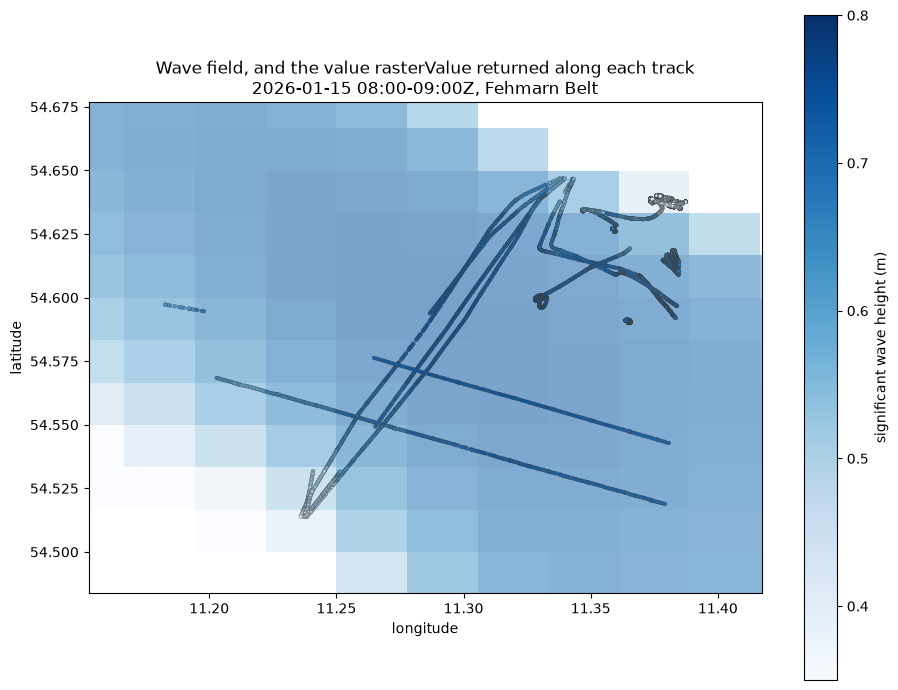

43,972 instants, 0.411..0.733 m


In [4]:
pts = c.execute(f"""
SELECT ST_X(getValue(inst)) AS lon,
       ST_Y(getValue(inst)) AS lat,
       valueAtTimestamp(wave, getTimestamp(inst)) AS wave_m
FROM (
  SELECT unnest(instants(g)) AS inst, rasterValue('{TIF}', g) AS wave
  FROM (SELECT transform(setSRID(tgeompointFromEWKB(traj), 32632), 4326) AS g
        FROM read_parquet('{TRIPS}') {WHERE})
)""").df()

lo, hi = 0.35, 0.80
fig, ax = plt.subplots(figsize=(9.5, 7))
ax.imshow(band, extent=extent, origin="upper", cmap="Blues",
          vmin=lo, vmax=hi, alpha=.55, interpolation="nearest")
sc = ax.scatter(pts.lon, pts.lat, c=pts.wave_m, s=7, cmap="Blues",
                vmin=lo, vmax=hi, edgecolors="0.25", linewidths=0.25)

pad = 0.03
ax.set_xlim(pts.lon.min() - pad, pts.lon.max() + pad)
ax.set_ylim(pts.lat.min() - pad, pts.lat.max() + pad)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("Wave field, and the value rasterValue returned along each track\n"
             "2026-01-15 08:00-09:00Z, Fehmarn Belt")
fig.colorbar(sc, ax=ax, label=f"{C.EO_VAR_LABEL} ({C.EO_VAR_UNIT})")
plt.tight_layout(); plt.show()
print(f"{len(pts):,} instants, {pts.wave_m.min():.3f}..{pts.wave_m.max():.3f} m")


## Predicates on the raster value

`eRasterValue` and `aRasterValue` ask whether the field was ever or always in
a range; `atRasterValue` keeps the part of the trajectory where it was.


In [5]:
print(c.execute(f"""
SELECT mmsi,
       eRasterValue('{TIF}', transform(setSRID(tgeompointFromEWKB(traj), 32632), 4326),
                    floatspan '[0.6, 9.0]') AS ever_over_0_6m,
       aRasterValue('{TIF}', transform(setSRID(tgeompointFromEWKB(traj), 32632), 4326),
                    floatspan '[0.6, 9.0]') AS always_over_0_6m
FROM read_parquet('{TRIPS}') {WHERE}
LIMIT 6""").df().to_string(index=False))


     mmsi  ever_over_0_6m  always_over_0_6m
211757540           False             False
211757540           False             False
219000431           False             False
219000429           False             False
219000429           False             False
211757540           False             False
